<h3 style="text-align:center;font-weight:bold">Exploratory Data Analysis (EDA) gives you better understanding of the data you are working with, and helps develop insights about the phenomenon of interest.</h3>
<h3 style="text-align:center;font-weight:bold">This script aims to extract preliminary spectral information from a subset of sample images, seeking for differences between the two features classes of interest: built-up area e and bare soil.</h3>

In [1]:
import os
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import f_classif

<h3 style="color:#CD5C5C;"> Functions</h3>

In [2]:
# Function to obtain the values of sample pixels (isolated).
def extract_pixels(gdf, bands_dict, img_dir):

    data = {}   # dictionary for the reflectance values of which band
    
    # Iterate over the band dictionary
    for name_band, file_band in bands_dict.items():

        file_name = next((f for f in os.listdir(img_dir) if f.endswith(file_band)), None)   # finds the file with the band's name

        if file_name:
            path_band = os.path.join(img_dir, file_name)    # file path
        
        with rasterio.open(path_band) as src:
            # Conversion of the reference system of the samples to that of the image
            gdf_reproj = gdf.to_crs(src.crs)
            
            values = [] # list for values
            # Extract value at the point
            for geom in gdf_reproj.geometry:
                
                x, y = geom.x, geom.y   # point coordinates
                row, col = src.index(x, y)  # index in the image matrix

                # Band:1 / Window 1x1: ((initial_line, final_line), (initial_column, final_column))
                # src.read() returns a numpy array - [0,0] access the first/single element
                valor = src.read(1, window=((row, row+1), (col, col+1)))[0, 0]
                values.append(valor)
            
            data[name_band] = values
    
    return data

In [3]:
# Extract pixel window around each sample point
def extract_pixels_window(file_samples, bands_dict, image_dir, image_list, window_size=9):

    data = {}   # dictionary for the reflectance values of which band

    half_window = window_size // 2

    # Iterates over folders containing images
    for dir in image_list:
        
        dir_samples = os.path.join(image_dir, dir)
        path_samples = os.path.join(dir_samples, file_samples)
        gdf = gpd.read_file(path_samples)  # full samples

        path_dir = os.path.join(image_dir, dir)

        for name_band, file_band in bands_dict.items():
            file_name = next((f for f in os.listdir(path_dir) if f.endswith(file_band)), None)
            
            if not file_name:
                print(f"File for the band {name_band} not found.")
                continue
                
            path_band = os.path.join(path_dir, file_name)
            
            with rasterio.open(path_band) as src:
                gdf_reproj = gdf.to_crs(src.crs)
                
                if name_band not in data:
                    data[name_band] = []
                
                for geom in gdf_reproj.geometry:
                    try:
                        x, y = geom.x, geom.y
                        row, col = src.index(x, y)
                        
                        # Calculates window boundaries ensuring fixed size
                        row_start = max(0, row - half_window)
                        row_end = row_start + window_size
                        if row_end > src.height:
                            row_end = src.height
                            row_start = max(0, row_end - window_size)
                        
                        col_start = max(0, col - half_window)
                        col_end = col_start + window_size
                        if col_end > src.width:
                            col_end = src.width
                            col_start = max(0, col_end - window_size)
                        
                        # Extracts the window
                        window_data = src.read(1, window=((row_start, row_end), (col_start, col_end)))
                        
                        # Ensures fixed size by filling with NaN if necessary
                        if window_data.shape != (window_size, window_size):
                            fixed_window = np.full((window_size, window_size), np.nan)
                            h, w = window_data.shape
                            fixed_window[:h, :w] = window_data
                            window_data = fixed_window
                        
                        data[name_band].append(window_data)
                    
                    except Exception as e:
                        print(f"Failed to extract window for point {geom}: {str(e)}")
                        data[name_band].append(np.full((window_size, window_size), np.nan))
    
    return data

In [20]:
# Function to plot histograms
def plot_histogram(builtup_area, bare_soil, bands_dict):

    rgb = ['B2', 'B3', 'B4']
    nir_swir = ['B8', 'B11', 'B12']

    # Determine axis limits based on all data
    all_rgb = np.concatenate([np.array(builtup_area[band]) for band in rgb] +
                [np.array(bare_soil[band]) for band in rgb])
    all_ns = np.concatenate([np.array(builtup_area[band]) for band in nir_swir] +
                [np.array(bare_soil[band]) for band in nir_swir])
    vmin_rgb, vmax_rgb = np.nanmin(all_rgb), np.nanmax(all_rgb)
    vmin_ns, vmax_ns = np.nanmin(all_ns), np.nanmax(all_ns)

    # Define fixed bins for the histograms
    bins_rgb = np.linspace(vmin_rgb, vmax_rgb)
    bins_ns = np.linspace(vmin_ns, vmax_ns)

    plt.figure(figsize=(15, 6))
    
    # Built-up - RGB
    plt.subplot(1, 2, 1)
    for band, color in zip(['B2', 'B3', 'B4'], ['blue', 'green', 'red']):
        plt.hist(np.array(builtup_area[band]), bins=bins_rgb, histtype='step', density=True, color=color, linewidth=2, label=f'{band}')
    plt.title(f'Built-up area - RGB')
    plt.xlabel('Surface reflectance (x10⁻⁴)')
    plt.xlim(vmin_rgb, vmax_rgb)
    plt.legend()
    
    # Built-up - NIR/SWIR
    plt.subplot(1, 2, 2)
    for band, color in zip(['B8', 'B11', 'B12'], ['darkred', 'orange', 'tomato']):
        plt.hist(np.array(builtup_area[band]), bins=bins_ns, histtype='step', density=True, color=color, linewidth=2, label=f'{band}')
    plt.title(f'Built-up area - NIR/SWIR')
    plt.xlabel('Surface reflectance (x10⁻⁴)')
    plt.xlim(vmin_ns, vmax_ns)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    # Bare soil - RGB
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    for band, color in zip(['B2', 'B3', 'B4'], ['blue', 'green', 'red']):
        plt.hist(np.array(bare_soil[band]), bins=bins_rgb, histtype='step', density=True, color=color, linewidth=2, label=f'{band}')
    plt.title(f'Bare soil - RGB')
    plt.xlabel('Surface reflectance (x10⁻⁴)')
    plt.xlim(vmin_rgb, vmax_rgb)
    plt.legend()
    
    # Bare soil - NIR/SWIR
    plt.subplot(1, 2, 2)
    for band, color in zip(['B8', 'B11', 'B12'], ['darkred', 'orange', 'tomato']):
        plt.hist(np.array(bare_soil[band]), bins=bins_ns, histtype='step', density=True, color=color, linewidth=2, label=f'{band}')
    plt.title(f'Bare soil - NIR/SWIR')
    plt.xlabel('Surface reflectance (x10⁻⁴)')
    plt.xlim(vmin_ns, vmax_ns)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [5]:
# Function to display the bar chart of the reflectance values ​​of the sampled pixels
def plot_band_values(builtup_area, bare_soil):
    
    # Obtain all RGB values to set y-axis 
    all_rgb = np.concatenate([np.array([builtup_area['B2'], builtup_area['B3'], builtup_area['B4']])] + 
                 [np.array([bare_soil['B2'],bare_soil['B3'], bare_soil['B4']])])
    
    # Obtain all NIR/SWIE values to set y-axis 
    all_nir_swir = np.concatenate([np.array([builtup_area['B8'], builtup_area['B11'], builtup_area['B12']])] + 
                 [np.array([bare_soil['B8'], bare_soil['B11'], bare_soil['B12']])])

    bar_width = 0.5  # bar width

    n_samples = len(builtup_area['B2']) # number of built-up area samples
    
    for i in range(n_samples):
        plt.figure(figsize=(15, 6))
        # Built-up - RGB
        plt.subplot(1, 2, 1)
        rgb_bands = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)']
        rgb_values = [builtup_area['B2'][i], builtup_area['B3'][i], builtup_area['B4'][i]]
        rgb_colors = ['blue', 'green', 'red']
        
        bars = plt.bar(rgb_bands, rgb_values, width=bar_width, 
                      color=rgb_colors, alpha=0.7)
        plt.title(f'Built-up area - Sample {chr(97 + i)}\nRGB bands') # sample code comes from ASCII table
        plt.ylabel('Surface reflectance')
        plt.ylim(0, np.nanmax(all_rgb)*1.2)
        
        # Add values above bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}',
                     ha='center', va='bottom')
        
        # Built-up - NIR/SWIR
        plt.subplot(1, 2, 2)
        nir_swir_bands = ['B8 (NIR)', 'B11 (SWIR1)', 'B12 (SWIR2)']
        nir_swir_values = [builtup_area['B8'][i], builtup_area['B11'][i], builtup_area['B12'][i]]
        nir_swir_colors = ['darkred', 'orange', 'tomato']
        
        bars = plt.bar(nir_swir_bands, nir_swir_values, width=bar_width,
                      color=nir_swir_colors, alpha=0.7)
        plt.title(f'Built-up area - Sample {chr(97 + i)}\nNIR/SWIR bands') # sample code comes from ASCII table
        plt.ylim(0, np.nanmax(all_nir_swir)*1.2)
        
        # Add values above bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}',
                     ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
    
    n_samples = len(bare_soil['B2']) # number of soil samples

    for i in range(n_samples):
        # Bare soil - RGB
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 2, 1)
        rgb_values = [bare_soil['B2'][i], bare_soil['B3'][i], bare_soil['B4'][i]]
        
        bars = plt.bar(rgb_bands, rgb_values, width=bar_width,
                      color=rgb_colors, alpha=0.7)
        plt.title(f'Bare soil - Sample {chr(100 + i)}\nRGB bands')
        plt.ylabel('Surface reflectance')
        plt.ylim(0, np.nanmax(all_rgb)*1.2)
        
        # Add values above bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}',
                     ha='center', va='bottom')
        
        # Bare soil - NIR/SWIR
        plt.subplot(1, 2, 2)
        nir_swir_values = [bare_soil['B8'][i], bare_soil['B11'][i], bare_soil['B12'][i]]
        
        bars = plt.bar(nir_swir_bands, nir_swir_values, width=bar_width,
                      color=nir_swir_colors, alpha=0.7)
        plt.title(f'Bare soil - Sample {chr(100 + i)}\nNIR/SWIR bands')
        plt.ylim(0, np.nanmax(all_nir_swir)*1.2)
        
        # Add values above bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}',
                     ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()

In [6]:
# Density histogram with both classes
def plot_comparative_histograms(builtup_window, soil_window, bins=30, alpha=0.7):
    plt.figure(figsize=(15, 10))
    
    # Colors and bands configs
    rgb_bands = ['B2', 'B3', 'B4']
    rgb_colors = ['blue', 'green', 'red']
    rgb_labels = ['Blue (B2)', 'Green (B3)', 'Red (B4)']
    nir_swir_bands = ['B8', 'B11', 'B12']
    nir_swir_colors = ['darkred', 'orange', 'tomato']
    nir_swir_labels = ['NIR (B8)', 'SWIR1 (B11)', 'SWIR2 (B12)']
    
    # Creating lists with sample window values ​​for each band
    builtup_processed = {}
    soil_processed = {}
    for band, window in builtup_window.items():
        builtup_processed[band] = [pixel for win in window for pixel in win.flatten()]
    for band, window in soil_window.items():
        soil_processed[band] = [pixel for win in window for pixel in win.flatten()]
    
    # Plot RGB
    plt.subplot(2, 1, 1)
    for band, color, label in zip(rgb_bands, rgb_colors, rgb_labels):
        plt.hist(builtup_processed[band], bins=bins, color=color, alpha=alpha, 
                 label=f'Built-up - {label}', density=True)
        plt.hist(soil_processed[band], bins=bins, color=color, alpha=alpha*0.6, 
                 label=f'Soil - {label}', density=True, histtype='step', linewidth=2)
    
    plt.title(f'Comparative Density Histogram - RGB Bands', fontsize=14)
    plt.xlabel('Surface reflectance (x10⁻⁴)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Plot NIR/SWIR
    plt.subplot(2, 1, 2)
    for band, color, label in zip(nir_swir_bands, nir_swir_colors, nir_swir_labels):
        plt.hist(builtup_processed[band], bins=bins, color=color, alpha=alpha, 
                 label=f'Built-up - {label}', density=True)
        plt.hist(soil_processed[band], bins=bins, color=color, alpha=alpha*0.6, 
                 label=f'Soil - {label}', density=True, histtype='step', linewidth=2)
    
    plt.title(f'Comparative Density Histogram - NIR/SWIR Bands', fontsize=14)
    plt.xlabel('Surface reflectance (x10⁻⁴)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

<h3 style="color:#CD5C5C;">Processing</h3>

#### First, we'll work with a few samples as example.

Defining some variables and structures

In [7]:
image_ex1 = 'img_data/example_1'  # example image dir of buil-up area
image_ex2 = 'img_data/example_2'  # example image dir of bare soil
image_dir = 'img_data'
image_list = ['fullscene_1', 'fullscene_2', 'fullscene_3'] # sampled images dir

builtup_area_ex = gpd.read_file('samples/builtup_area.gpkg')  # examples of class pixels
bare_soil_ex = gpd.read_file('samples/bare_soil.gpkg')        # examples of class pixels

# Dictionary of the bands of interest from Sentinel-2
bands_dict = {
    'B2': 'B02_10m.jp2',    # Blue
    'B3': 'B03_10m.jp2',    # Green
    'B4': 'B04_10m.jp2',    # Red
    'B8': 'B08_10m.jp2',    # NIR
    'B11': 'B11_20m.jp2',   # SWIR 1
    'B12': 'B12_20m.jp2'    # SWIR 2
}


In [8]:
# Extract example values ​​from each class
data_builtup_area_ex = extract_pixels(builtup_area_ex, bands_dict, image_ex1)
data_bare_soil_ex = extract_pixels(bare_soil_ex, bands_dict, image_ex2)

There are 3 samples of each class that represents different situations found during sampling.

Characteristics of built-up areas samples:
- Sample *a*: tiles;
- Sample *b*: construction;
- Sample *c*: asphalt;

Characteristics of bare soil samples:
- Sample *d*: with a purple/grayish appearance;
- Sample *e*: brown;
- Sample *f*: with liming;

![Sample examples](samples_examples.png)

#### Histogram plot

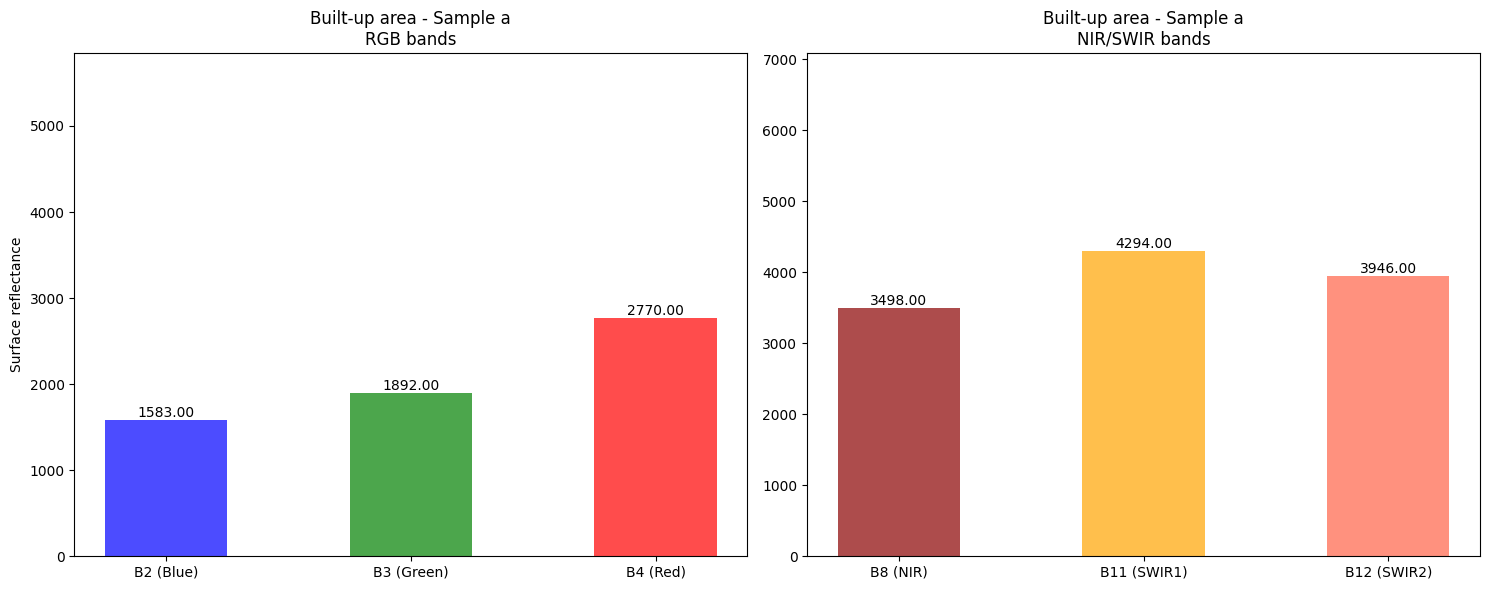

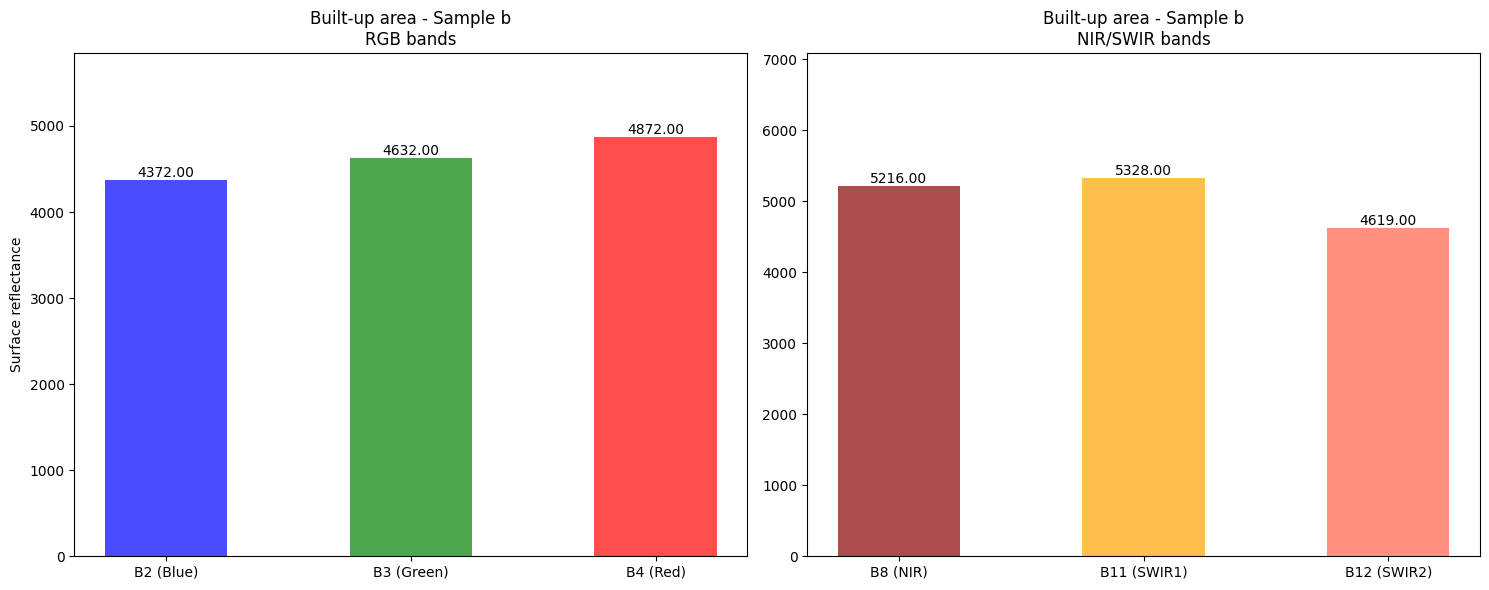

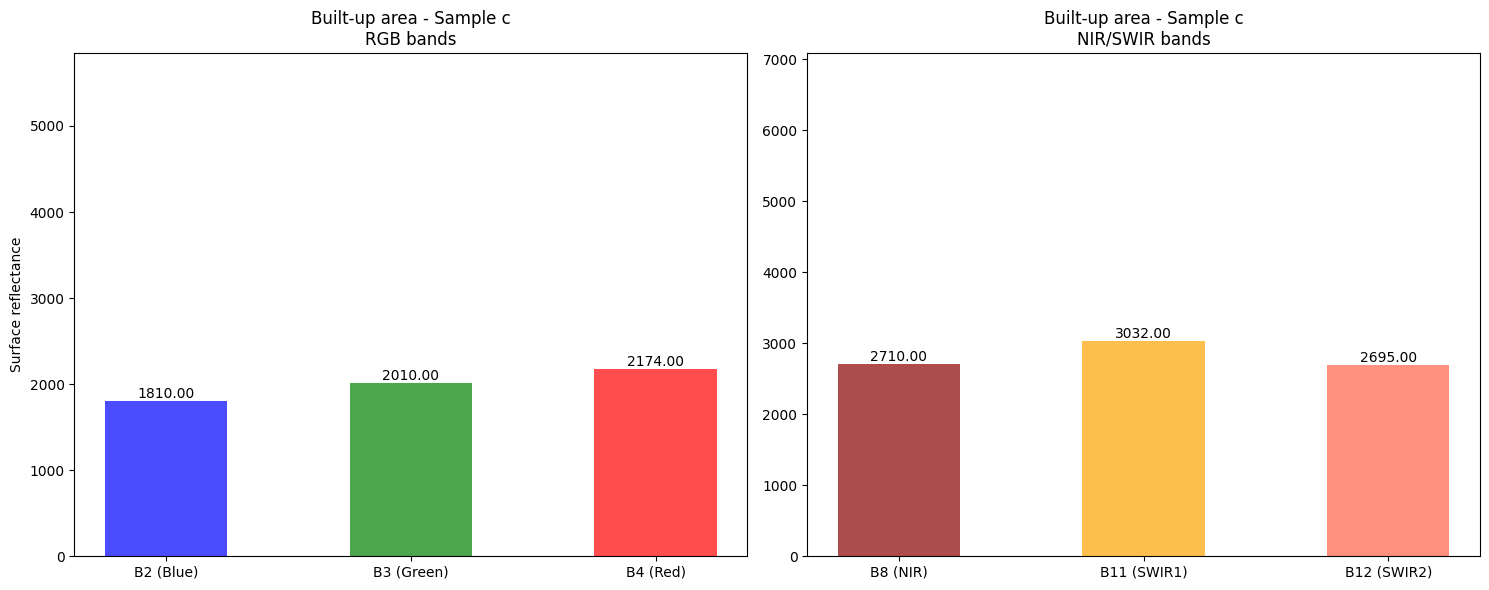

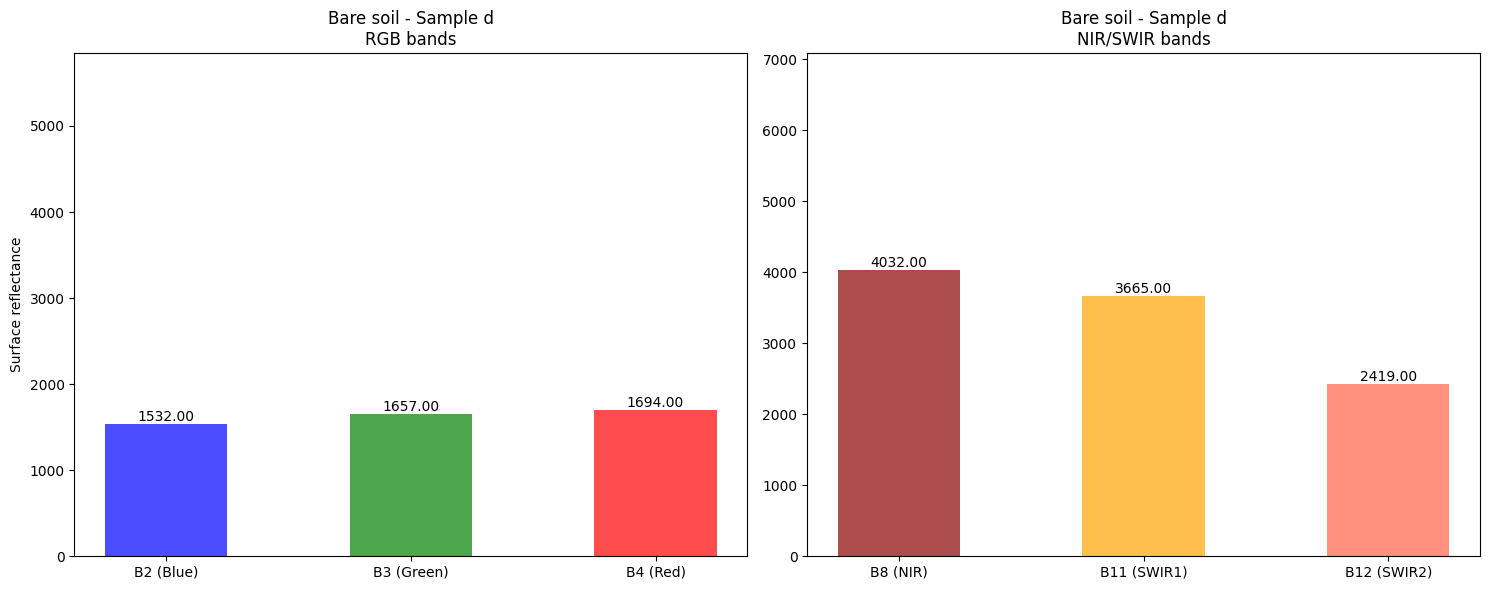

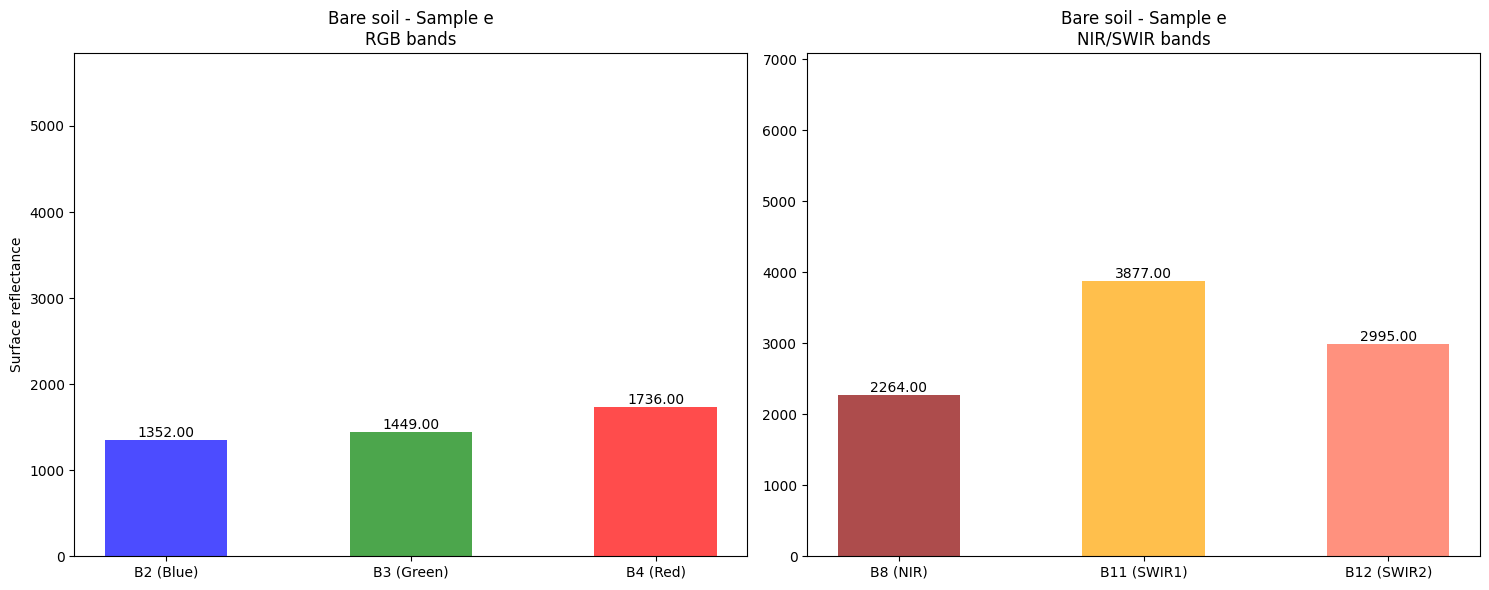

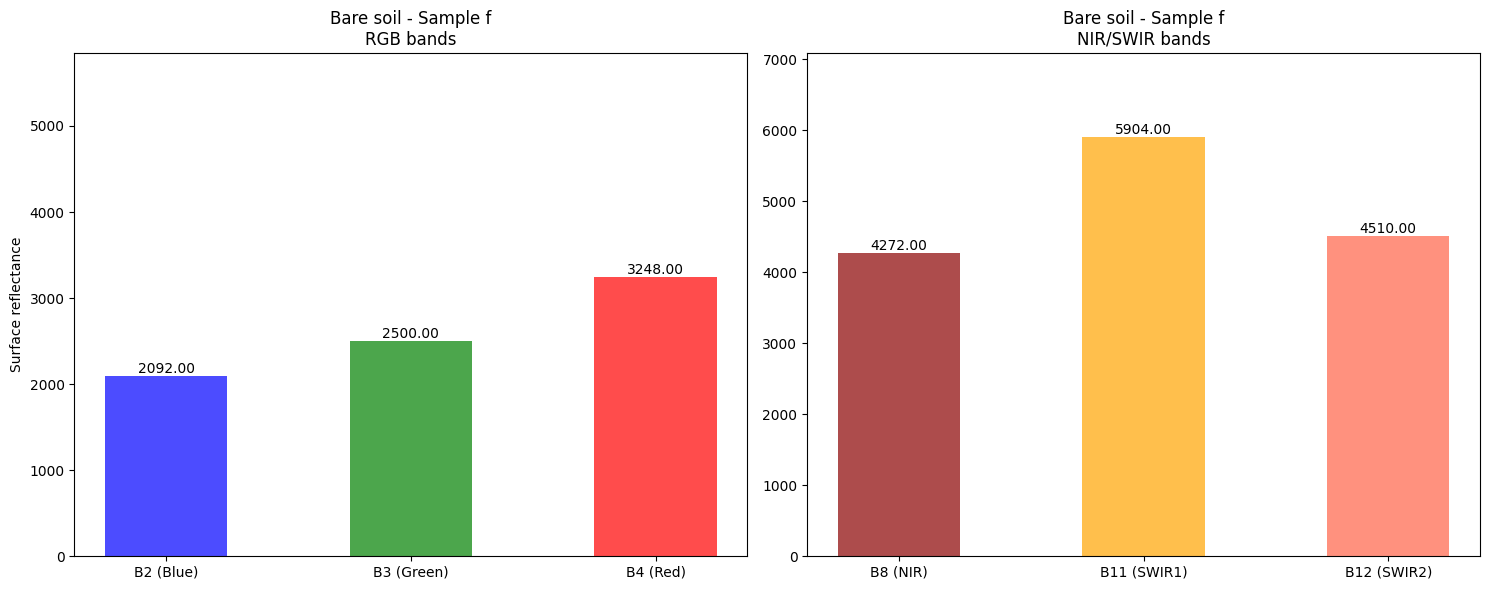

In [9]:
plot_band_values(data_builtup_area_ex, data_bare_soil_ex)

Insights from the histograms:
- Sample *b*, which is made of a highly reflective construction material, and Sample *f*, which is a very light soil (due to the limestone) and is also reflective, have very different RGB bands responses within their classes, presenting higher values.
- Samples *b* and *f* also presented values well above the average for NIR and SWIR.
- Other samples had relatively similar behavior in RGB. The RGB values ​​are relatively low, with red standing out sometimes.
- There is no clear definition of NIR and SWIR values ​​for each class.

#### Scatter Plot Matrix helps identifying the separability between classes.

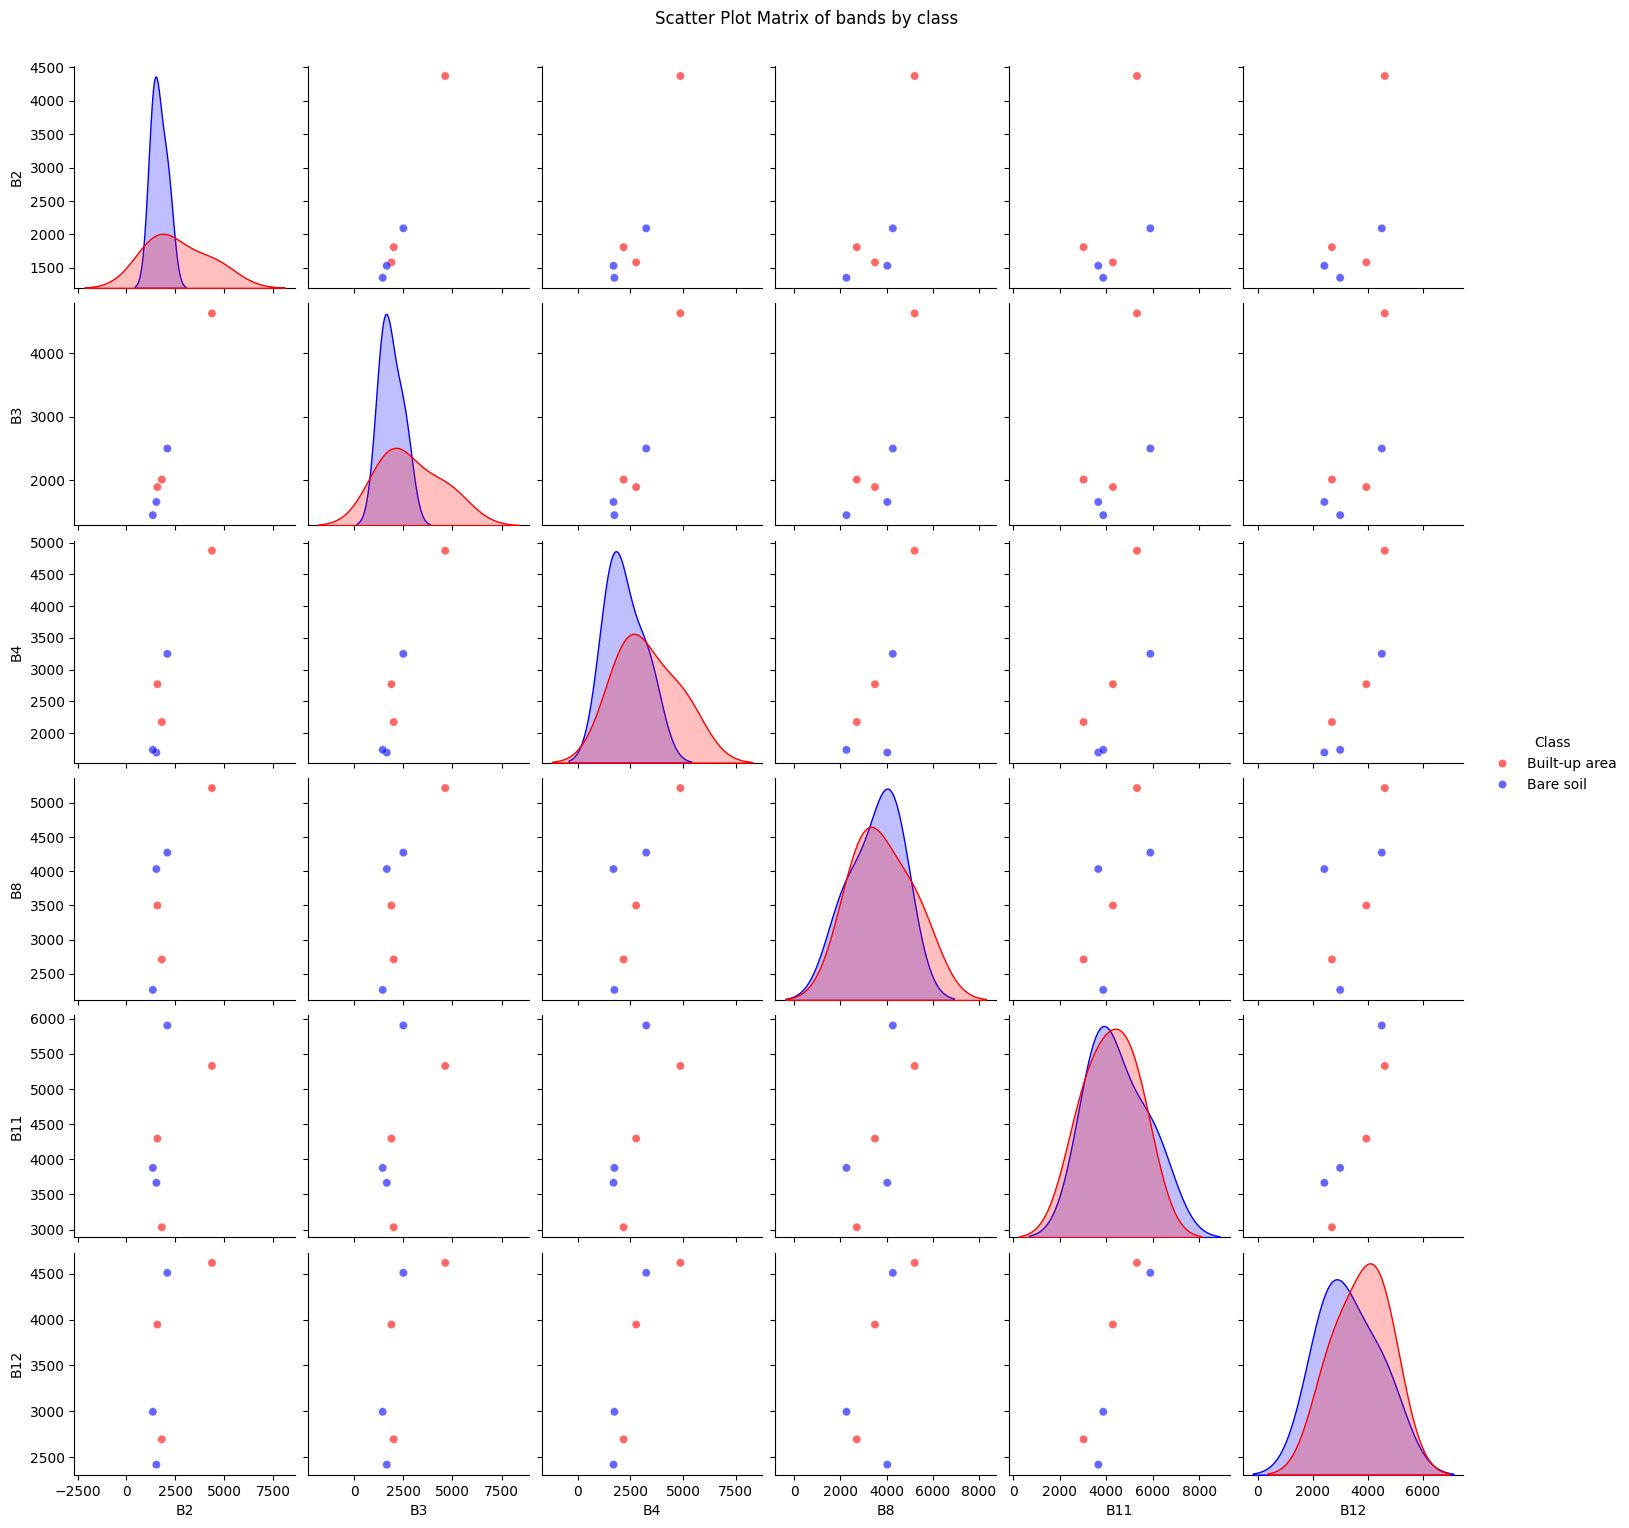

In [24]:
# Create combined DataFrame of examples
df_builtup_ex = pd.DataFrame(data_builtup_area_ex)
df_builtup_ex['Class'] = 'Built-up area'
df_soil_ex = pd.DataFrame(data_bare_soil_ex)
df_soil_ex['Class'] = 'Bare soil'
df_ex = pd.concat([df_builtup_ex, df_soil_ex])

# Scatter matrix
sns.pairplot(df_ex, vars=['B2', 'B3', 'B4', 'B8', 'B11', 'B12'], 
             hue='Class', palette={'Built-up area':'red', 'Bare soil':'blue'},
             plot_kws={'alpha':0.6})
plt.suptitle('Scatter Plot Matrix of bands by class', y=1.02)
plt.show()

- There is a high value overlapping between the two classes in B8, B11 e B12.
- B2 e B3 has better separabilitty.
- Sample *f* (with liming), which presented higher values ​​within the soil class, ends up being mixed with the built-up area samples.

###
### Now, with a larger sample set, let's consider blocks of pixels by extracting 9x9 pixel windows.

In [11]:
# Extract pixel blocks (window 9x9) from each class
data_builtup_area = extract_pixels_window('builtup_area.gpkg', bands_dict, image_dir, image_list)
data_bare_soil = extract_pixels_window('bare_soil.gpkg', bands_dict, image_dir, image_list)

In [12]:
# Creating lists for the pixel windows

array_builtup = {}
array_soil = {}

for band, windows in data_builtup_area.items():
    all_values = [win.flatten() for win in windows]
    all_values = np.concatenate(all_values)
    array_builtup[band] = all_values[~np.isnan(all_values)] # remove valores nan

for band, windows in data_bare_soil.items():
    all_values = [win.flatten() for win in windows]
    all_values = np.concatenate(all_values)
    array_soil[band] = all_values[~np.isnan(all_values)] # remove valores nan

# Create DataFrames from the lists
df_builtup = pd.DataFrame(array_builtup)
df_soil = pd.DataFrame(array_soil)

Numbers related to the size of dataset.

In [13]:
# Checking samples size
n_samples_builtup = len(next(iter(data_builtup_area.values())))
n_samples_soil = len(next(iter(data_bare_soil.values())))

print(n_samples_builtup)
print(n_samples_soil)
print(len(df_builtup))
print(len(df_soil))

402
764
32562
61884


#### Displaying the three most present values ​​of each band:

In [14]:
# Statistics of the most present values
print('\t\tBuilt-up area\t\tBare soil\n')
for band in df_builtup.columns:
    most_repeated_builtup = df_builtup[band].value_counts().iloc[0:3]
    most_repeated_soil = df_soil[band].value_counts().iloc[0:3]
    values_b = ', '.join([f'{val}' for val in most_repeated_builtup.index])
    values_s = ', '.join([f'{val}' for val in most_repeated_soil.index])
    print(f'Band {band}\t{values_b}\t{values_s}\n')

		Built-up area		Bare soil

Band B2	1794, 1822, 1764	1756, 1780, 1772

Band B3	2058, 2050, 2108	2078, 2086, 2058

Band B4	2606, 2526, 2350	2636, 2626, 2610

Band B8	3244, 3236, 3094	4620, 4472, 4444

Band B11	4087, 3969, 3852	5845, 5941, 5950

Band B12	3713, 4148, 3600	4431, 4414, 4405



#### Density Histogram

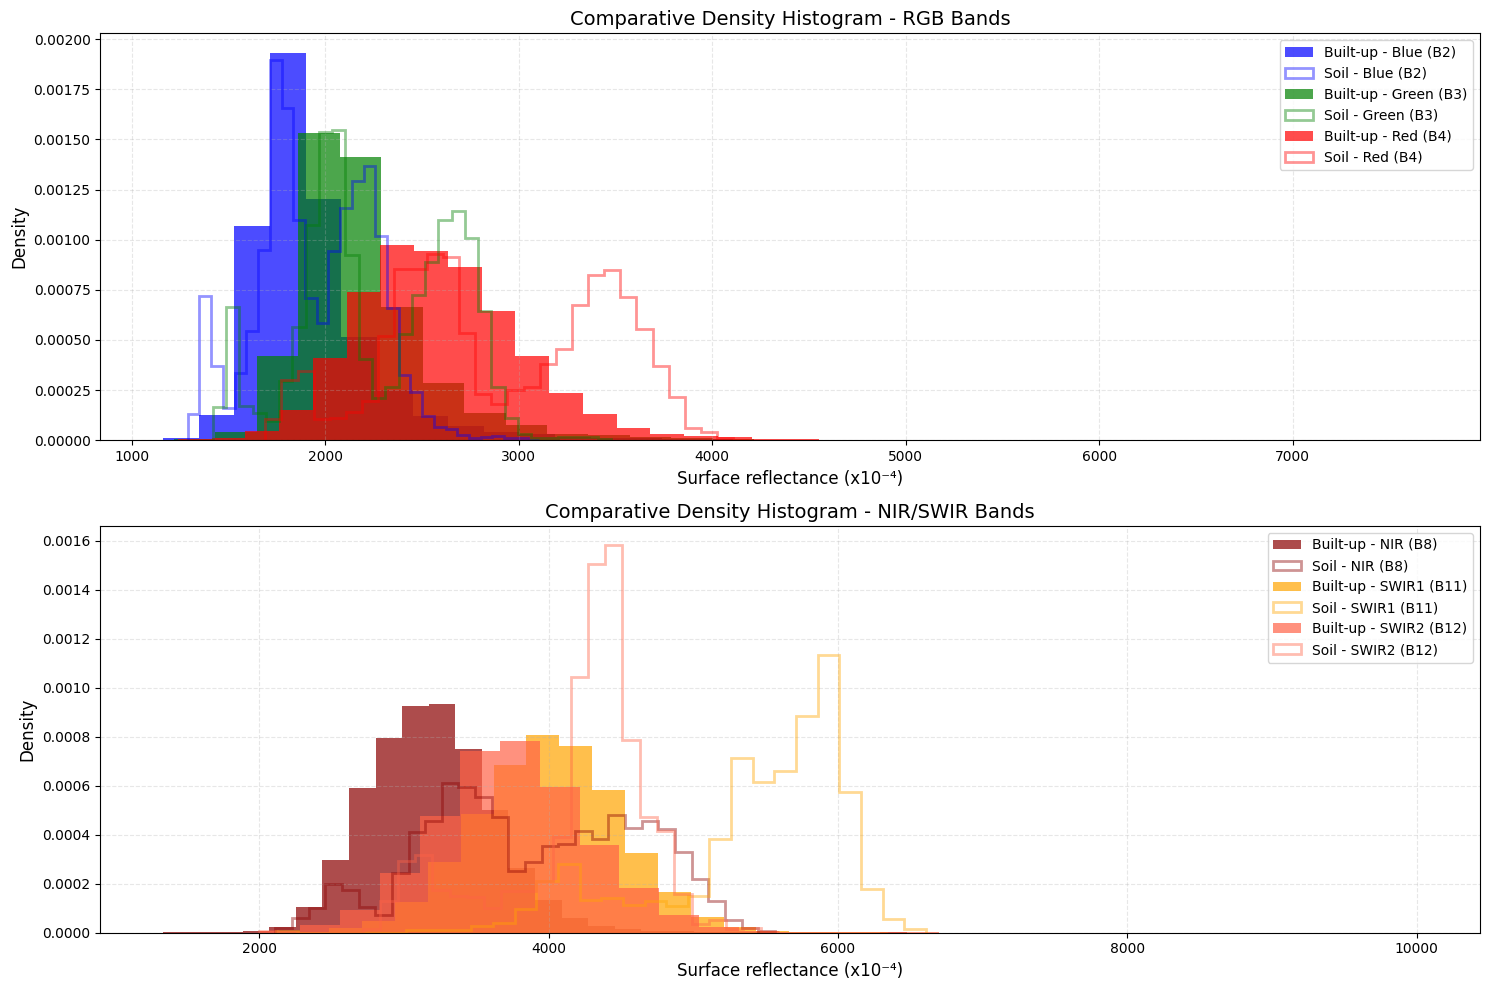

In [16]:
# Density histogram for both classes
plot_comparative_histograms(data_builtup_area, data_bare_soil)

RGB
- The highest density peaks in Blue and Green for both classes overlap.
- In Green, the soil class has a second density peak.
- In Red, on the other hand, there is a more pronounced shift between the histograms of the classes, with greater separability.

NIR/SWIR
- The greatest differences appear here. Soil has high concentrations of values ​​mainly in the SWIR that have no equivalent in built-up class. SWIR-1, in the case of soil, has a range of values ​​that is quite displaced in relation to the other class, with comparatively higher values.

#### Individual histograms for better view:

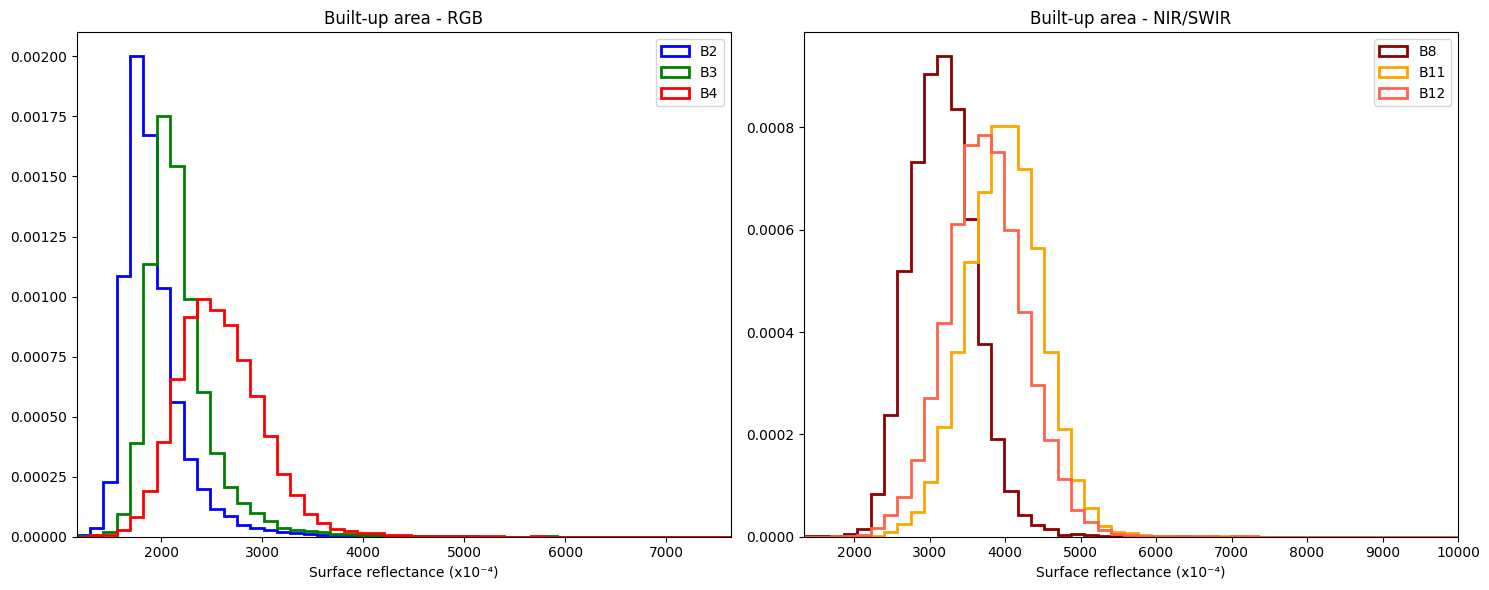

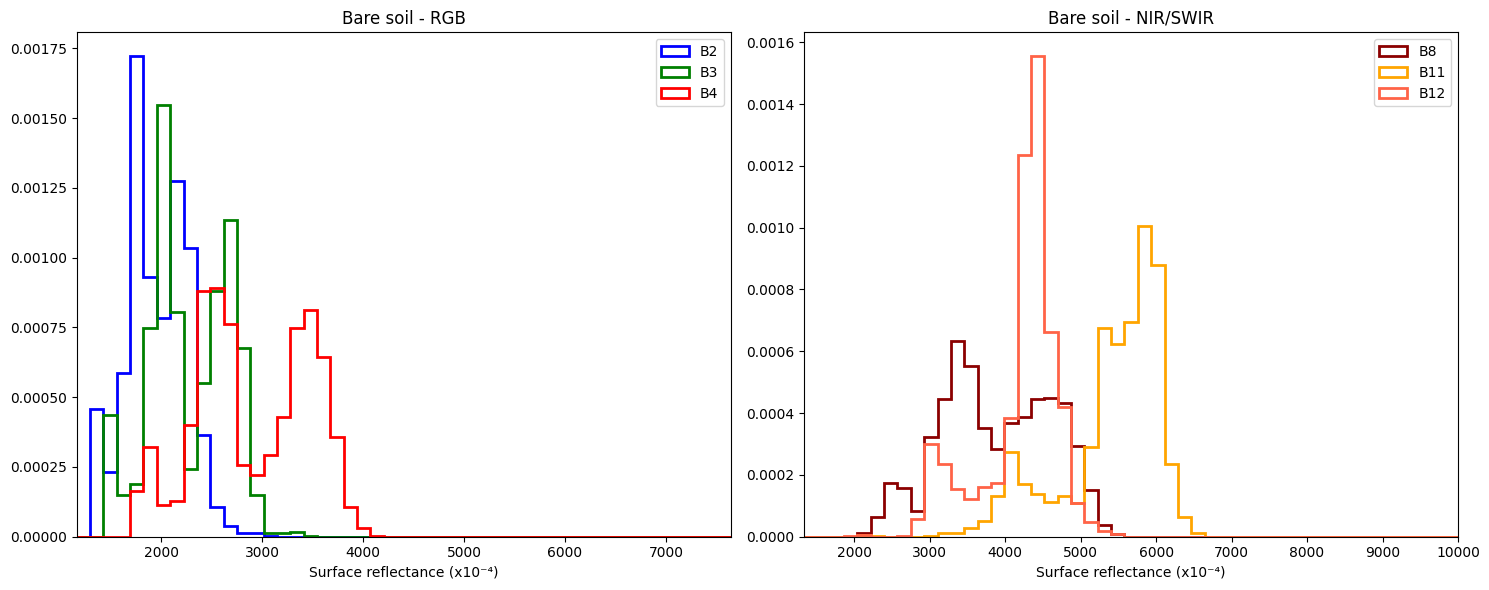

In [23]:
# Individual histograms for each class
plot_histogram(array_builtup, array_soil, bands_dict)

#### Correlation between bands

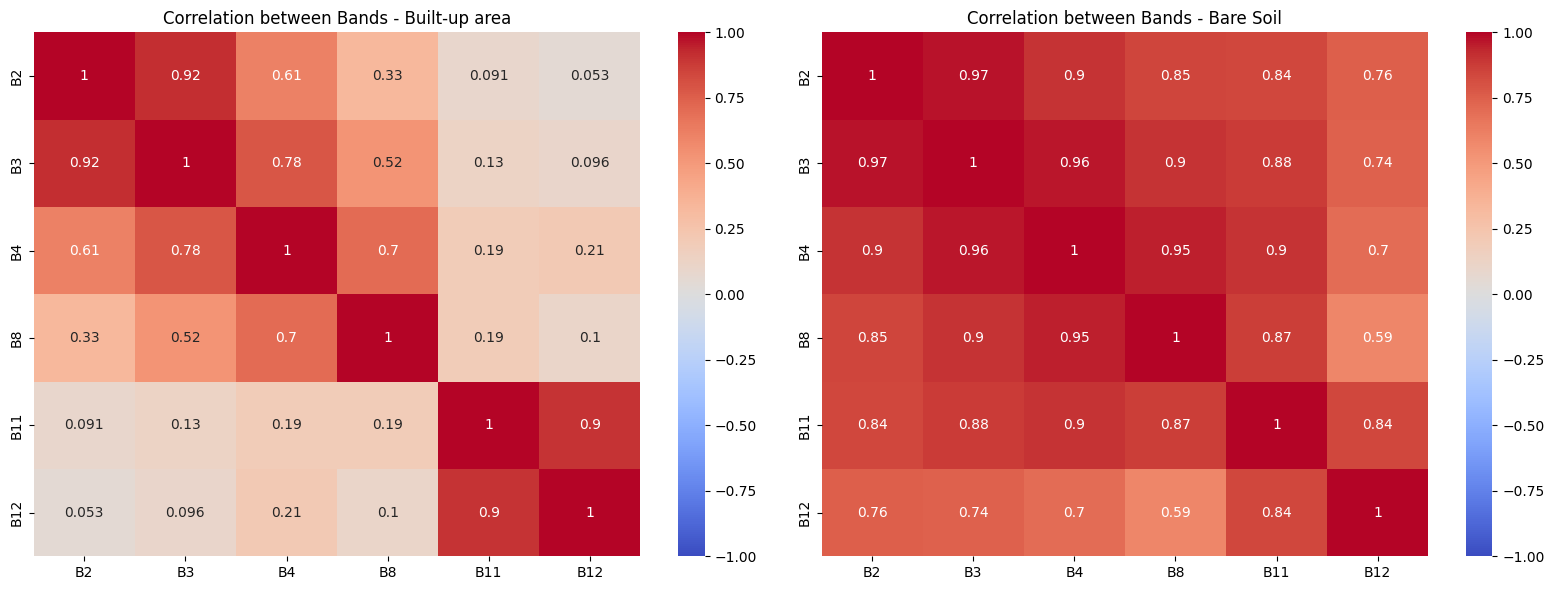

In [22]:
# Correlation between bands
corr_builtup = df_builtup.corr(method='spearman', numeric_only=True)
corr_soil = df_soil.corr(method='spearman', numeric_only=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_builtup, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Correlation between Bands - Built-up area')

sns.heatmap(corr_soil, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Correlation between Bands - Bare Soil')
plt.tight_layout()
plt.show()

- High positive correlation between practically all bands in bare soil (except B8 and B12), mainly between the RGB bands and between B8/B4.
- There are many cases of very low correlation in built-up class; the highest correlations occur between B2/B3 and between B11/B12.

### Feature score

#### The application of feature score to the spectral bands aims to evaluate the importance of each one in the separation between classes.

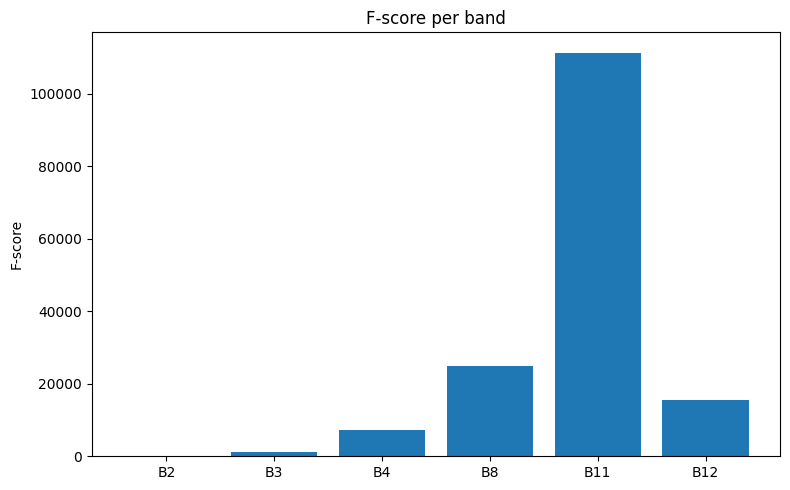

In [21]:
# Feature score of the bands: importance of each variable (spectral band) in the separation between classes
from sklearn.feature_selection import SelectKBest, f_regression

# Combinando os dados dos dois DFs
X = pd.concat([df_builtup, df_soil], ignore_index=True)
# Criar os rótulos para os dados de x
y = np.concatenate([
    np.ones(len(df_builtup)),     # classe 1: área urbana
    np.zeros(len(df_soil))        # classe 0: solo exposto
])

selector = SelectKBest(score_func=f_regression, k=1)
selector.fit(X, y)

feature_scores = selector.scores_

bands = X.columns

# Plotar
plt.figure(figsize=(8,5))
plt.bar(bands, feature_scores)
plt.title('F-score per band')
plt.ylabel('F-score')
plt.tight_layout()
plt.show()

- SWIR-1 showed the highest discriminatory ability, followed by NIR.